# Persistence analysis

In [13]:
# Import packages

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import numpy as np
from scipy import stats
from scipy.stats import mannwhitneyu, wilcoxon

In [14]:
#USER INPUT

data_folder_path = '/Users/laureleblanc/Desktop/Collective-twitching-2026/3_trajectory_analysis/persistence/dataset'
output_path = '/Users/laureleblanc/Desktop/Collective-twitching-2026/3_trajectory_analysis/persistence/graphes'
results_path = '/Users/laureleblanc/Desktop/Collective-twitching-2026/3_trajectory_analysis/persistence/results'

In [15]:
# Function used to compute PERSISTENCE = 1/SINOSITY

def plot_persistence_analysis(data_folder, results_folder):
    strains = {'232': 'deepskyblue', '177': 'magenta', '459': 'darkorange'}
    strain_labels = {'232': '\u2206pilH', '177': 'WT', '459': '\u2206pilG'}
    surface_coverages = ['SC10pc', 'SC70pc']
    
    csv_files = glob.glob(os.path.join(data_folder, '*.csv'))

    # Plot persistence for each single-cell trajectories (saved but not shown)
    for strain, color in strains.items():
        plt.figure(figsize=(5, 4))
        x_positions = [1, 2, 3, 5, 6, 7]
        x_labels = ['R1', 'R2', 'R3', 'R1', 'R2', 'R3']
        all_medians = []
        file_index = 0
        
        for i, sc in enumerate(surface_coverages):
            individual_medians = []
            for file in csv_files:
                if strain in file and sc in file:
                    df = pd.read_csv(file)
                    persistence_values = 1 / df['SINUOSITY'].dropna()
                    
                    if file_index < len(x_positions):
                        plt.scatter([x_positions[file_index]] * len(persistence_values), persistence_values, color=color, alpha=0.3)
                        median_value = persistence_values.median()
                        individual_medians.append(median_value)
                        plt.scatter(x_positions[file_index], median_value, color=color, edgecolor='black', s=100)
                        file_index += 1
            
            global_median = pd.Series(individual_medians).median()
            all_medians.append(global_median)
            if sc == 'SC10pc':
                plt.plot(x_positions[:3], [global_median] * 3, color=color, linestyle='--', linewidth=2)
            else:
                plt.plot(x_positions[3:], [global_median] * 3, color=color, linestyle='--', linewidth=2)
        
        plt.xticks(x_positions, x_labels)
        plt.xlabel('Replicates', fontsize=18, fontweight='bold', fontname='Arial', labelpad=25)
        plt.ylabel('Persistence', fontsize=18, fontweight='bold', fontname='Arial')
        plt.tick_params(axis='x', labelsize=16)
        plt.tick_params(axis='y', labelsize=16)
        plt.ylim(0, 1)  # Adjust based on your expected range
        plt.text(2, -0.15, 'Low density', fontsize=18, fontname='Arial', ha='center', va='top')
        plt.text(6, -0.15, 'High density', fontsize=18, fontname='Arial', ha='center', va='top')
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        plt.gca().spines['left'].set_linewidth(1.25)
        plt.gca().spines['bottom'].set_linewidth(1.25)
        plt.tight_layout()
        plt.savefig(os.path.join(results_folder, f'persistence_distribution_strain_{strain}.png'), dpi=300, bbox_inches='tight', transparent=True)
        plt.close()
    
    # Plot persistence vs density
    plt.figure(figsize=(5, 5))
    normalized_medians = {strain: None for strain in strains}
    
    for strain, color in strains.items():
        global_medians = {}
        for sc in surface_coverages:
            individual_medians = []
            for file in csv_files:
                if strain in file and sc in file:
                    df = pd.read_csv(file)
                    individual_medians.append((1 / df['SINUOSITY']).median())
            
            global_median = pd.Series(individual_medians).median()
            global_medians[sc] = global_median
            
            plt.scatter([sc] * len(individual_medians), individual_medians, color=color, alpha=0.3, s=50)
            plt.scatter(sc, global_medians[sc], color=color, edgecolor='black', s=150, zorder=5,
                        label=(r'$\it{' + strain_labels[strain] + '}$' if strain != '177' else strain_labels[strain]) if sc == 'SC10pc' else "")
        
        plt.plot(surface_coverages, [global_medians[sc] for sc in surface_coverages], color=color, linestyle='-', linewidth=5)
        normalized_medians[strain] = global_medians['SC10pc']

    plt.xlabel("Density", fontsize=24, fontweight='bold', fontname='Arial')
    plt.ylabel("Persistence", fontsize=24, fontweight='bold', fontname='Arial')
    plt.xticks(ticks=[0, 1], labels=['Low', 'High'])
    plt.xlim(-0.3, 1.3)
    plt.tick_params(axis='x', labelsize=20)
    plt.tick_params(axis='y', labelsize=20)
    plt.ylim(0, 0.8)
    plt.yticks(ticks=[0, 0.2, 0.4, 0.6, 0.8])
    plt.legend(loc='upper left', fontsize=16, frameon = False)
    plt.tight_layout()
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['left'].set_linewidth(1.25)
    plt.gca().spines['bottom'].set_linewidth(1.25)
    plt.savefig(os.path.join(results_folder, 'persistence_vs_density.png'), dpi=300, bbox_inches='tight', transparent=True)
    #plt.close()
    
    # Plot normalized persistence vs density
    plt.figure(figsize=(5, 5))
    for strain, color in strains.items():
        if normalized_medians[strain] is None:
            continue
        
        global_medians = {}
        for sc in surface_coverages:
            individual_medians = []
            for file in csv_files:
                if strain in file and sc in file:
                    df = pd.read_csv(file)
                    individual_medians.append((1 / df['SINUOSITY']).median() / normalized_medians[strain])
        
            global_median = pd.Series(individual_medians).median()
            global_medians[sc] = global_median
            
            plt.scatter([sc] * len(individual_medians), individual_medians, color=color, alpha=0.3, s=100)
        
        plt.plot(surface_coverages, [global_medians[sc] for sc in surface_coverages], color=color, linestyle='-', linewidth=5)
        
        for sc in surface_coverages:
            plt.scatter(sc, global_medians[sc], color=color, edgecolor='black', s=150, zorder=5,
                        label=(r'$\it{' + strain_labels[strain] + '}$' if strain != '177' else strain_labels[strain]) if sc == 'SC10pc' else "")

    plt.axhline(y=1, color='black', linestyle=':', linewidth=2)
    plt.xlabel("Density", fontsize=24, fontweight='bold', fontname='Arial')
    plt.ylabel("Normalized Persistence", fontsize=24, fontweight='bold', fontname='Arial')
    plt.ylim(0.2, 1.7)
    plt.xticks(ticks=[0, 1], labels=['Low', 'High'])
    plt.xlim(-0.3, 1.3)
    plt.tick_params(axis='x', labelsize=20)
    plt.tick_params(axis='y', labelsize=20)
    plt.yticks(ticks=[0.5, 1, 1.5])
    plt.legend(loc='lower left', fontsize=16, frameon = False)
    plt.tight_layout()
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['left'].set_linewidth(1.25)
    plt.gca().spines['bottom'].set_linewidth(1.25)
    plt.gca().tick_params(axis='both', which='major', length=7, width=1.25, color='black')
    plt.gca().tick_params(axis='both', which='minor', length=4, width=1.25, color='black')
    plt.savefig(os.path.join(results_folder, 'normalized_persistence_vs_density.png'), dpi=300, bbox_inches='tight', transparent=True)


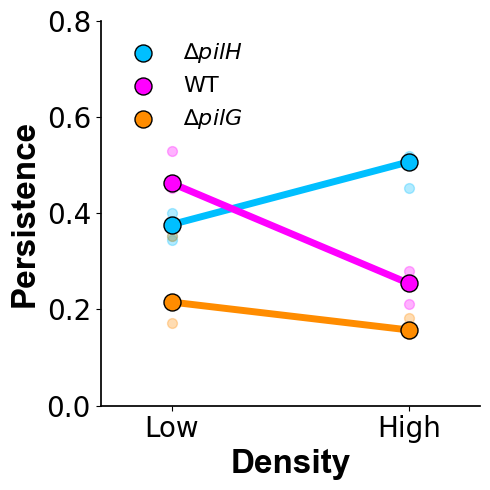

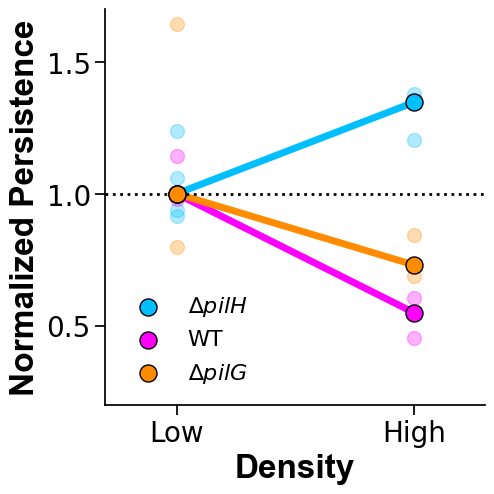

In [16]:
plot_persistence_analysis(data_folder_path, output_path)

# Statistical analysis

In [17]:
# Build dataframes to perform statistical tests

def build_persistence_dataframes(data_folder):
    # Map strain codes to readable names
    strain_map = {'177': 'WT', '232': 'pilH', '459': 'pilG'}
    surface_coverages = ['SC10pc', 'SC70pc']

    # Initialize empty dicts to hold persistence values for each SC
    data_low = {strain: [] for strain in strain_map.values()}
    data_high = {strain: [] for strain in strain_map.values()}

    csv_files = glob.glob(os.path.join(data_folder, '*.csv'))

    # Loop through each strain and surface coverage
    for strain_code, strain_name in strain_map.items():
        for sc in surface_coverages:
            for file in csv_files:
                if strain_code in file and sc in file:
                    df = pd.read_csv(file)
                    persistence_values = 1 / df['SINUOSITY'].dropna()

                    if sc == 'SC10pc':
                        data_low[strain_name].extend(persistence_values)
                    elif sc == 'SC70pc':
                        data_high[strain_name].extend(persistence_values)

    # Create dataframes
    df_low = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data_low.items()]))
    df_high = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data_high.items()]))
    
    return df_low, df_high


In [18]:
df_low, df_high = build_persistence_dataframes(data_folder_path)
df_low.to_csv(results_path + "/df_low.csv", index=False)
df_high.to_csv(results_path + "/df_high.csv", index=False)

In [19]:
# Statistical tests

def compare_groups(df_low, df_high):
    results = []
    
    # Within-strain comparisons (low vs high) — paired
    for strain in df_low.columns:
        x = df_low[strain].dropna()
        y = df_high[strain].dropna()
        # Only keep matched pairs
        min_len = min(len(x), len(y))
        stat, p = wilcoxon(x[:min_len], y[:min_len])
        results.append({
            'Comparison': f'{strain} low vs high',
            'p-value': p,
            'Test': 'Wilcoxon'
        })
        
    # Convert to DataFrame
    results_df = pd.DataFrame(results)

    # Function to assign significance stars
    def p_to_stars(p):
        if p < 0.0001:
            return '****'
        elif p < 0.001:
            return '***'
        elif p < 0.01:
            return '**'
        elif p < 0.05:
            return '*'
        else:
            return 'ns'

    results_df['Significance'] = results_df['p-value'].apply(p_to_stars)
    
    # Format p-values in scientific notation
    results_df['p-value'] = results_df['p-value'].apply(lambda x: f"{x:.2e}")

    return results_df


In [20]:
results_df = compare_groups(df_low, df_high)
print(results_df)

         Comparison   p-value      Test Significance
0    WT low vs high  2.25e-14  Wilcoxon         ****
1  pilH low vs high  6.25e-03  Wilcoxon           **
2  pilG low vs high  9.40e-07  Wilcoxon         ****
